<a href="https://colab.research.google.com/github/s-badev/pdf-ai-assistant-rag/blob/main/PDF_AI_Assistant_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Survive AI PDF Assistant

This notebook implements a PDF-based AI assistant in Google Colab.

It retrieves information from a PDF and returns answers as text, image, or audio.

## Setup

Before running the notebook:

1. Add your own `OPENAI_API_KEY` in Google Colab Secrets.
2. Make sure notebook access to the secret is enabled.
3. Run all cells.

The required PDF file is included in the GitHub repository and is downloaded automatically by the notebook.

> **Important:** The OpenAI API key is not included in this repository for security reasons. Each user must provide their own API key with available credit/billing.

In [1]:
!pip install -q openai chromadb pypdf pydantic

In [2]:
from google.colab import userdata
import os
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

print("client is ready")

client is ready


In [3]:
import requests
import os

PDF_URL = "https://raw.githubusercontent.com/s-badev/pdf-ai-assistant-rag/main/Survive-AI.pdf"
PDF_PATH = "/content/Survive-AI.pdf"

if not os.path.exists(PDF_PATH):
    response = requests.get(PDF_URL)

    if response.status_code == 200:
        with open(PDF_PATH, "wb") as file:
            file.write(response.content)
        print("PDF downloaded successfully.")
    else:
        raise FileNotFoundError("PDF could not be downloaded from GitHub.")

print("PDF path:", PDF_PATH)

PDF path: /content/Survive-AI.pdf


# Extract content from the PDF file

In [4]:
# Import the libraries needed to load and read the PDF file
from pypdf import PdfReader
from pathlib import Path

# Load the PDF file from the Colab session storage
pdf_path = Path("/content/Survive-AI.pdf")

if not pdf_path.exists():
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")

reader = PdfReader(str(pdf_path))

# Extract text from all pages and combine it into one string
full_text = ""
for page in reader.pages:
    text = page.extract_text()
    if text:
        full_text += text + "\n"

# Show basic document statistics
print(f"Loaded PDF: {pdf_path.name}")
print(f"Total pages: {len(reader.pages)}")
print(f"Total characters: {len(full_text)}")

Loaded PDF: Survive-AI.pdf
Total pages: 171
Total characters: 209237


# Chunk the PDF content

In [5]:
# Split the extracted text into overlapping chunks for embedding and retrieval
def split_text(text, chunk_size=1200, overlap=200):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        start += chunk_size - overlap

    return chunks

chunks = split_text(full_text)

print("chunks created successfully")
print(f"Total chunks: {len(chunks)}")

chunks created successfully
Total chunks: 210


# Create embeddings and store them in Chroma

In [6]:
# Create and manage the Chroma vector database
import chromadb

# Generate embeddings in batches to avoid sending too much text at once
def embed_texts(texts, batch_size=50):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        response = client.embeddings.create(
            model="text-embedding-3-small",
            input=batch
        )
        all_embeddings.extend([item.embedding for item in response.data])

    return all_embeddings

doc_embeddings = embed_texts(chunks)

# Create a fresh Chroma collection for the current notebook run
chroma_client = chromadb.Client()
collection_name = "survive_ai_book_v2"

try:
    chroma_client.delete_collection(name=collection_name)
except Exception:
    pass

openai_collection = chroma_client.get_or_create_collection(name=collection_name)

# Store chunks, embeddings, and ids in the vector database
openai_collection.add(
    documents=chunks,
    embeddings=doc_embeddings,
    ids=[f"chunk_{i}" for i in range(len(chunks))]
)

print("OpenAI collection created successfully.")
print(f"Total documents: {openai_collection.count()}")

OpenAI collection created successfully.
Total documents: 210


# Retrieve information from the PDF

In [7]:
# Retrieve the most relevant chunks from Chroma and answer using only that context
def retrieve_information(prompt):
    query_embedding = client.embeddings.create(
        model="text-embedding-3-small",
        input=prompt
    ).data[0].embedding

    results = openai_collection.query(
        query_embeddings=[query_embedding],
        n_results=5
    )

    context = "\n\n".join(results["documents"][0])

    response = client.responses.create(
        model="gpt-5-nano",
        input=f"""
Answer the user's question using ONLY the context below.
If the answer is not in the context, say exactly:
I could not find the answer in the PDF.

Context:
{context}

Question:
{prompt}
"""
    )

    return response.output_text

# Parse the user question with Structured Output

In [8]:
import json

def parse_question(question):
    response = client.responses.create(
        model="gpt-5-nano",
        input=[
            {
                "role": "developer",
                "content": (
                    "Extract two things from the user's request: "
                    "1) the actual question for the PDF as 'prompt'; "
                    "2) the requested output format as 'format'. "
                    "Allowed formats: text, image, audio. "
                    "If the user does not specify a format, use text."
                )
            },
            {
                "role": "user",
                "content": question
            }
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "question_request",
                "schema": {
                    "type": "object",
                    "properties": {
                        "prompt": {"type": "string"},
                        "format": {
                            "type": "string",
                            "enum": ["text", "image", "audio"]
                        }
                    },
                    "required": ["prompt", "format"],
                    "additionalProperties": False
                },
                "strict": True
            }
        }
    )

    return json.loads(response.output_text)

# Generate image and audio outputs

In [9]:
# Create image and audio outputs based on the retrieved answer from the PDF
import base64
import uuid
from IPython.display import Image as IPyImage, Audio, display


def generate_image_from_answer(user_question, answer_text, output_path=None):
    if output_path is None:
        output_path = f"answer_{uuid.uuid4().hex[:8]}.png"

    image_response = client.images.generate(
        model="gpt-image-1",
        prompt=f"""
Create ONE realistic visual scene based ONLY on the PDF-based answer below.

User question:
{user_question}

Answer from the PDF:
{answer_text}

Task:
Turn the answer into one specific real-world scene that clearly represents its meaning.

Requirements:
- Show one concrete situation, not a generic AI office image
- Use visible actions, people, tools, and surroundings that directly match the answer
- Focus on people, interaction, work activity, and environment
- Make the scene specific, believable, and tightly connected to the answer
- No text anywhere in the image
- No letters
- No words
- No numbers
- No labels
- No captions
- No titles
- No posters
- No slides
- No whiteboards with writing
- No charts with labels
- No dashboards
- No chat windows
- No visible app interface
- No readable content on any screen
- If a laptop or monitor is visible, the screen must be dark, blank, blurred, or turned away from the viewer
- Do not place the camera close to a screen
- Do not make the screen the focus of the scene
- Keep it realistic, cinematic, clean, and easy to understand
""",
        size="1024x1024"
    )

    image_base64 = image_response.data[0].b64_json
    image_bytes = base64.b64decode(image_base64)

    with open(output_path, "wb") as f:
        f.write(image_bytes)

    return output_path


def generate_audio_from_answer(answer_text, output_path=None):
    if output_path is None:
        output_path = f"answer_{uuid.uuid4().hex[:8]}.mp3"

    speech_response = client.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="alloy",
        input=answer_text
    )

    speech_response.write_to_file(output_path)
    return output_path

# Main AI assistant function

In [10]:
def ask_ai(question):
    parsed = parse_question(question)

    prompt = parsed["prompt"]
    output_format = parsed["format"]

    answer = retrieve_information(prompt)

    if output_format == "text":
        return answer

    elif output_format == "image":
        image_path = generate_image_from_answer(
            user_question=question,
            answer_text=answer
        )
        return image_path

    elif output_format == "audio":
        audio_path = generate_audio_from_answer(answer)
        return audio_path

# Test cases

In [11]:
# Test the assistant with sample questions in all supported output formats

test_questions = [
    "What are the five profit hotspots?",
    "Explain the 4-part prompt framework.",
    "What does the book say about deploying AI with zero dev team?",
    "Summarize the common myths about AI.",
    "What are the key steps for getting started with AI in a business?",
    "What does the book say about measuring success in AI adoption?",
    "Create an image answer about deploying AI with zero dev team.",
    "Read as audio: explain the 4-part prompt framework."
]

for i, q in enumerate(test_questions, 1):
    print(f"\nTEST {i}: {q}")
    result = ask_ai(q)
    print(result)
    print("-" * 60)


TEST 1: What are the five profit hotspots?
- Customer Service
- Marketing & Sales
- Operations & Supply
- Product Development
- Decision Support
------------------------------------------------------------

TEST 2: Explain the 4-part prompt framework.
- The 4-Part Prompt Framework consists of:
  1) Context: The situation or role you want the AI to adopt. It gives the model background so responses align with reality.
  2) Task / Question: The specific action or answer you need. It focuses the model on a single objective.
  3) Input / Constraints: Any data, examples, style rules, or limits. It eliminates guessing and reduces hallucination.
  4) Output Format: How you want the answer delivered (bullets, table, tone). It saves editing time and ensures consistency.
------------------------------------------------------------

TEST 3: What does the book say about deploying AI with zero dev team?
The book says you can deploy AI with zero dev team by:
- Grabbing an off-the-shelf platform (Cha

# Image output example

Generated image: answer_5b1fa778.png


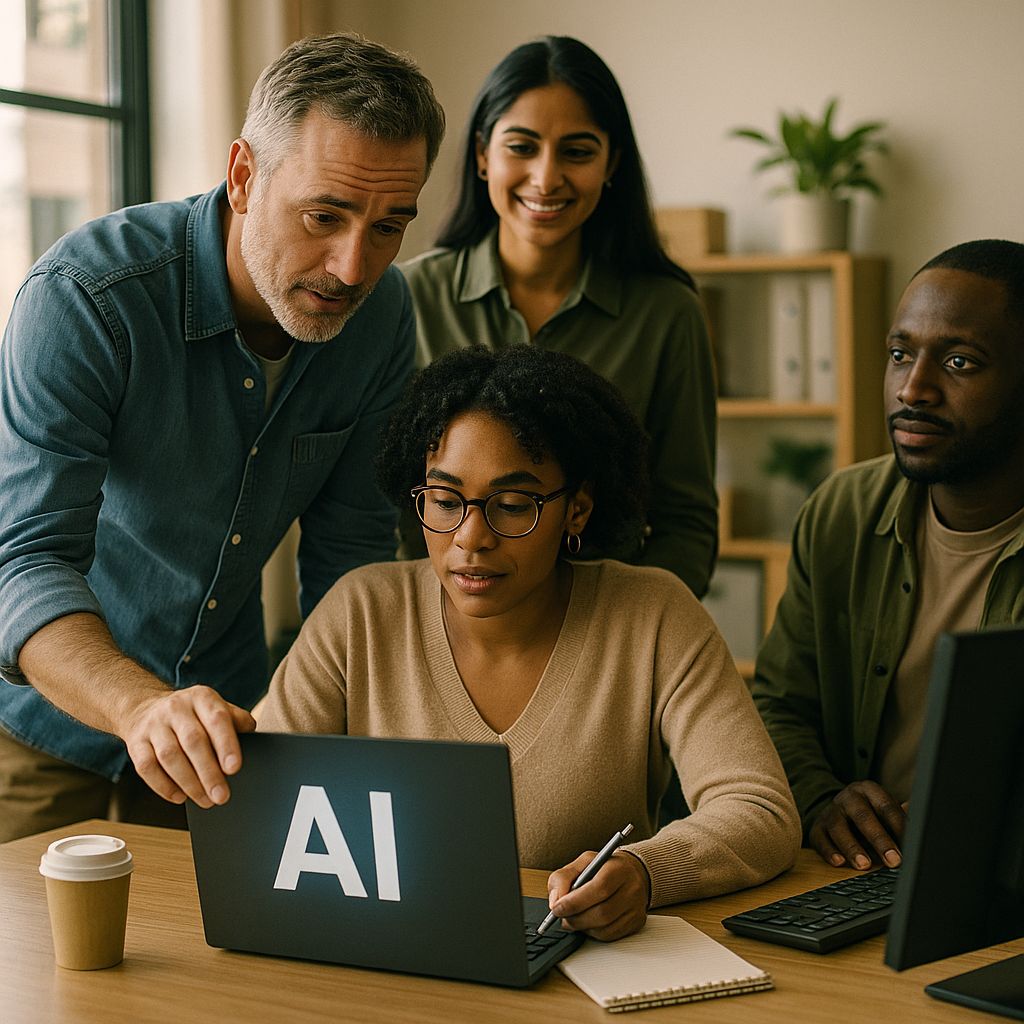

In [12]:
# Generate and display an example image response based on the PDF answer

last_image = ask_ai("Create an image answer about deploying AI with zero dev team.")
print("Generated image:", last_image)

if not str(last_image).lower().endswith(".png"):
    raise ValueError(f"Expected PNG file path, but got: {last_image}")

from IPython.display import Image as IPyImage, display
display(IPyImage(filename=last_image))

# Audio output example

In [13]:
# Generate and play an example audio response based on the PDF answer

last_audio = ask_ai("Read as audio: explain the 4-part prompt framework.")
print("Generated audio:", last_audio)

if not str(last_audio).lower().endswith(".mp3"):
    raise ValueError(f"Expected MP3 file path, but got: {last_audio}")

from IPython.display import Audio, display
display(Audio(filename=last_audio, autoplay=False))

Generated audio: answer_05deb4f0.mp3
